In [12]:
from google.colab import files
uploaded = files.upload()

Saving enron_40_60.csv to enron_40_60.csv


In [14]:
print(df.columns.tolist())
print()
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())

['Category', 'Message']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values per column:
Category    0
Message     0
dtype: int64


In [15]:
import pandas as pd

df = pd.read_csv("enron_40_60.csv")
print("Shape:", df.shape)
df.head()

Shape: (27575, 2)


,Category,Message
0,spam,"re : loonger hello , do you want to spend iess..."
1,ham,unify to sap interfaces - - - - - - - - - - - ...
2,ham,start date : 1 / 28 / 02 ; hourahead hour : 10...
3,spam,want to make a million ! ! ! ! ! ! ! ! ! ! ! !...
4,ham,key dates and impact of upcoming sap implement...


In [16]:
print("Missing values per column:")
print(df.isnull().sum())

before = df.shape[0]
df = df.dropna(subset=["Category", "Message"]).drop_duplicates(subset=["Message"]).reset_index(drop=True)
after = df.shape[0]
print(f"\nRows before: {before} | after: {after} | removed: {before - after}")

df["label_num"] = df["Category"].map({"ham": 0, "spam": 1})
print()
print(df["Category"].value_counts())
print((df["Category"].value_counts(normalize=True) * 100).round(2))

Missing values per column:
Category    0
Message     0
dtype: int64

Rows before: 27575 | after: 25865 | removed: 1710

Category
ham     15910
spam     9955
Name: count, dtype: int64
Category
ham     61.51
spam    38.49
Name: proportion, dtype: float64


/tmp/ipykernel_2022/2346874789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Category", data=df, palette=["#4C9AFF", "#FF6B6B"])


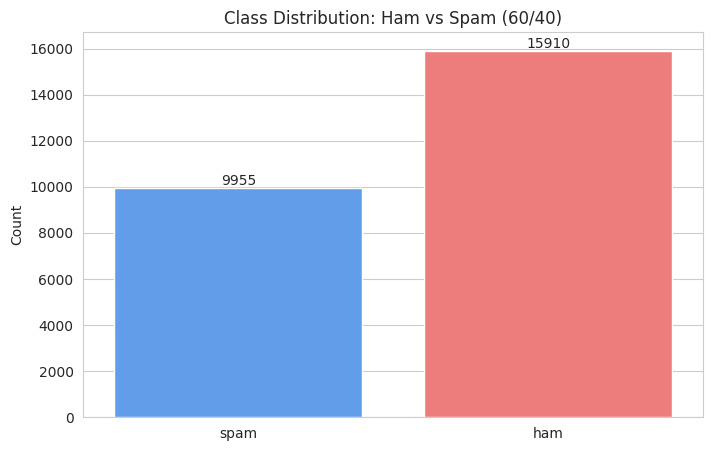

In [17]:
plt.figure()
ax = sns.countplot(x="Category", data=df, palette=["#4C9AFF", "#FF6B6B"])
plt.title("Class Distribution: Ham vs Spam (60/40)")
plt.xlabel("")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

KeyError: 'char_count'

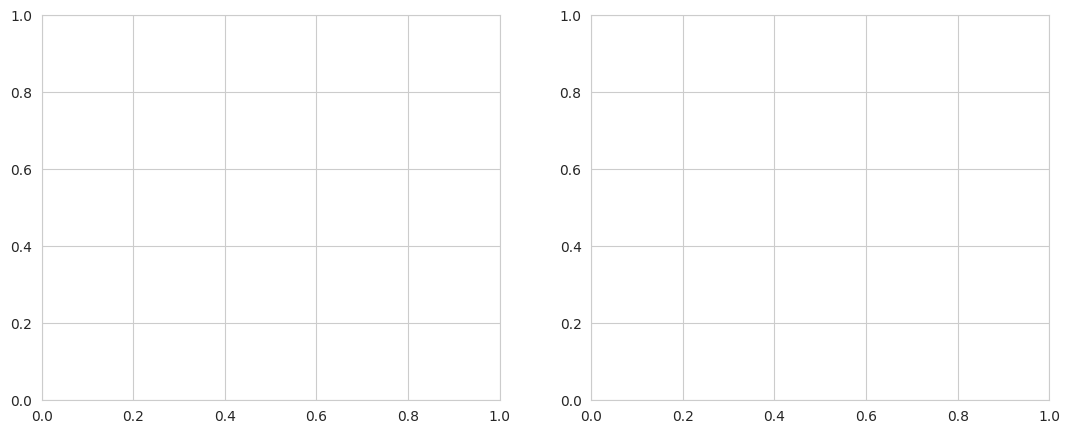

In [18]:
from scipy import stats
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color in zip(axes, ["char_count", "word_count"], ["#4C9AFF", "#FF6B6B"]):
    data = df[col]

    # Actual histogram (density scale so it matches the curve)
    ax.hist(data, bins=50, density=True, color=color, alpha=0.6, edgecolor="white")

    # Ideal normal curve using this data's own mean and std
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")

    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve")
    ax.legend()

plt.tight_layout()
plt.show()

In [19]:
df["char_count"] = df["Message"].apply(len)
df["word_count"] = df["Message"].apply(lambda x: len(x.split()))

df[["char_count", "word_count"]].describe()

,char_count,word_count
count,25865.000000,25865.000000
mean,1507.214421,313.896037
std,4400.425626,877.194044
min,3.000000,1.000000
25%,343.000000,72.000000
50%,728.000000,157.000000
75%,1581.000000,340.000000
max,228368.000000,45450.000000


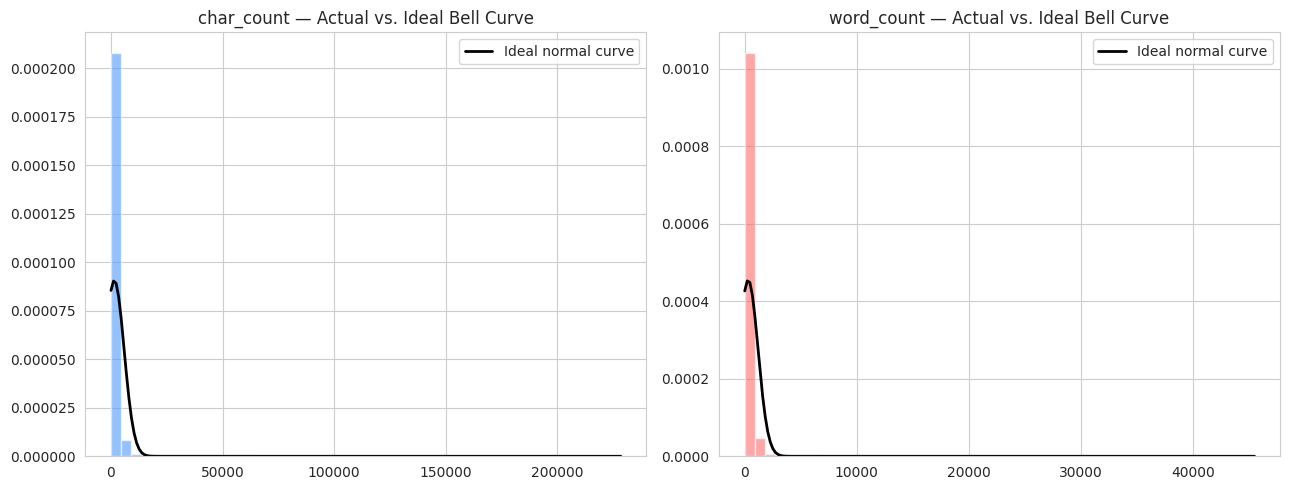

In [20]:
from scipy import stats
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color in zip(axes, ["char_count", "word_count"], ["#4C9AFF", "#FF6B6B"]):
    data = df[col]

    # Actual histogram (density scale so it matches the curve)
    ax.hist(data, bins=50, density=True, color=color, alpha=0.6, edgecolor="white")

    # Ideal normal curve using this data's own mean and std
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")

    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve")
    ax.legend()

plt.tight_layout()
plt.show()

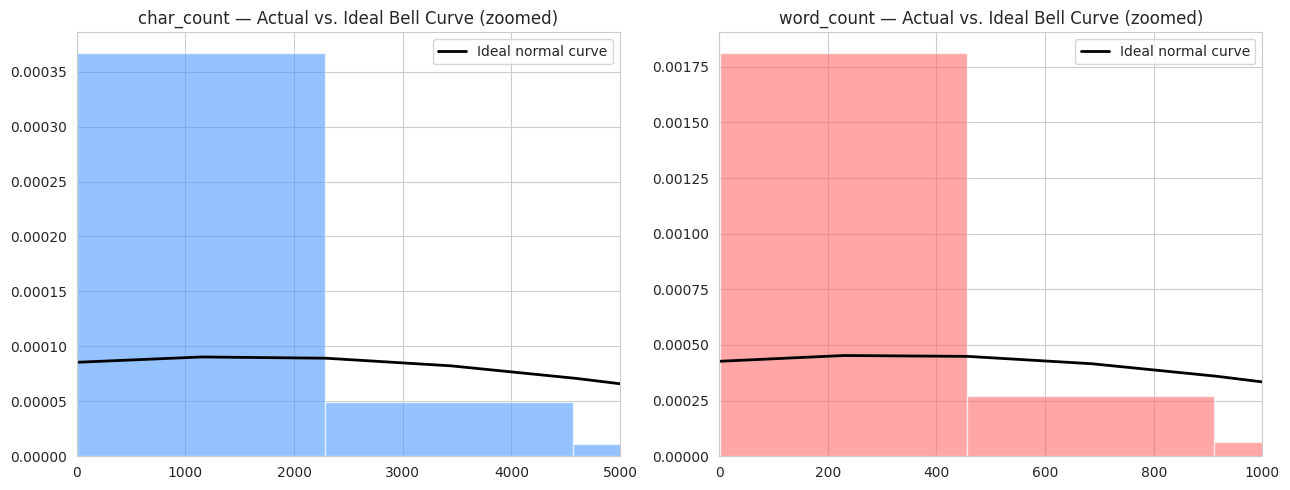

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, xlim in zip(axes, ["char_count", "word_count"], ["#4C9AFF", "#FF6B6B"], [5000, 1000]):
    data = df[col]
    ax.hist(data, bins=100, density=True, color=color, alpha=0.6, edgecolor="white")

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")

    ax.set_xlim(0, xlim)  # zoom in so the real shape is visible
    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve (zoomed)")
    ax.legend()

plt.tight_layout()
plt.show()

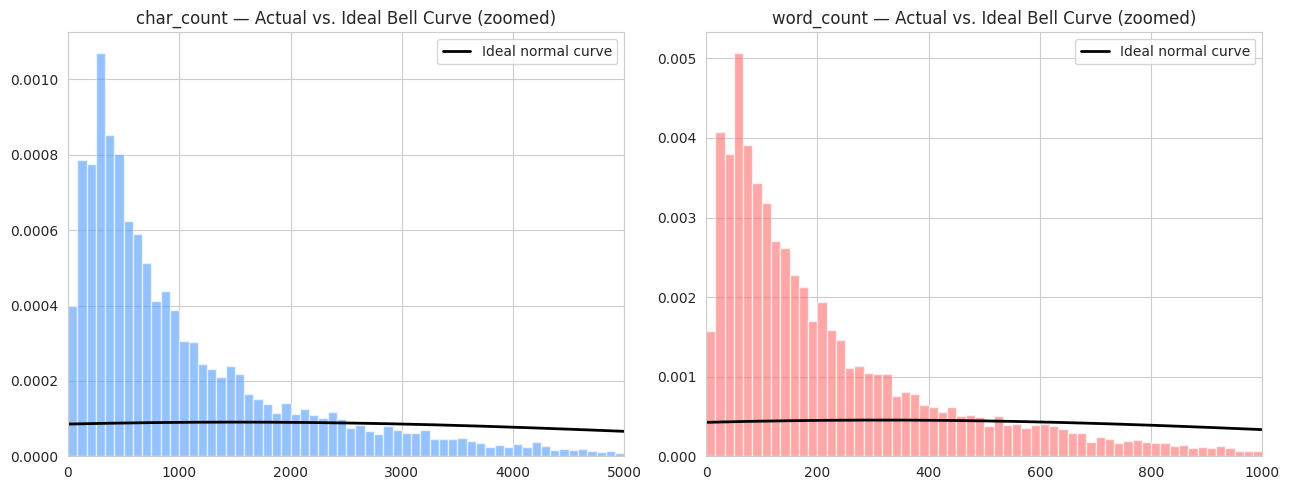

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs = [("char_count", "#4C9AFF", 5000), ("word_count", "#FF6B6B", 1000)]

for ax, (col, color, xlim) in zip(axes, configs):
    data = df[col]
    ax.hist(data, bins=60, range=(0, xlim), density=True, color=color, alpha=0.6, edgecolor="white")

    mu, sigma = data.mean(), data.std()
    x = np.linspace(0, xlim, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")

    ax.set_xlim(0, xlim)
    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve (zoomed)")
    ax.legend()

plt.tight_layout()
plt.show()

In [23]:
def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper

mask_char, low_c, up_c = iqr_outlier_mask(df["char_count"])
mask_word, low_w, up_w = iqr_outlier_mask(df["word_count"])
outlier_mask = mask_char | mask_word

print(f"char_count bounds: [{low_c:.1f}, {up_c:.1f}]")
print(f"word_count bounds: [{low_w:.1f}, {up_w:.1f}]")
print(f"Outliers flagged: {outlier_mask.sum()} out of {len(df)} rows ({outlier_mask.mean()*100:.2f}%)")
print()
print("Outlier breakdown by class:")
print(df[outlier_mask]["Category"].value_counts())

char_count bounds: [-1514.0, 3438.0]
word_count bounds: [-330.0, 742.0]
Outliers flagged: 2243 out of 25865 rows (8.67%)

Outlier breakdown by class:
Category
ham     1398
spam     845
Name: count, dtype: int64


In [24]:
df_clean = df[~outlier_mask].reset_index(drop=True)
print(f"Rows before: {len(df)} | after: {len(df_clean)} | removed: {len(df) - len(df_clean)}")

Rows before: 25865 | after: 23622 | removed: 2243


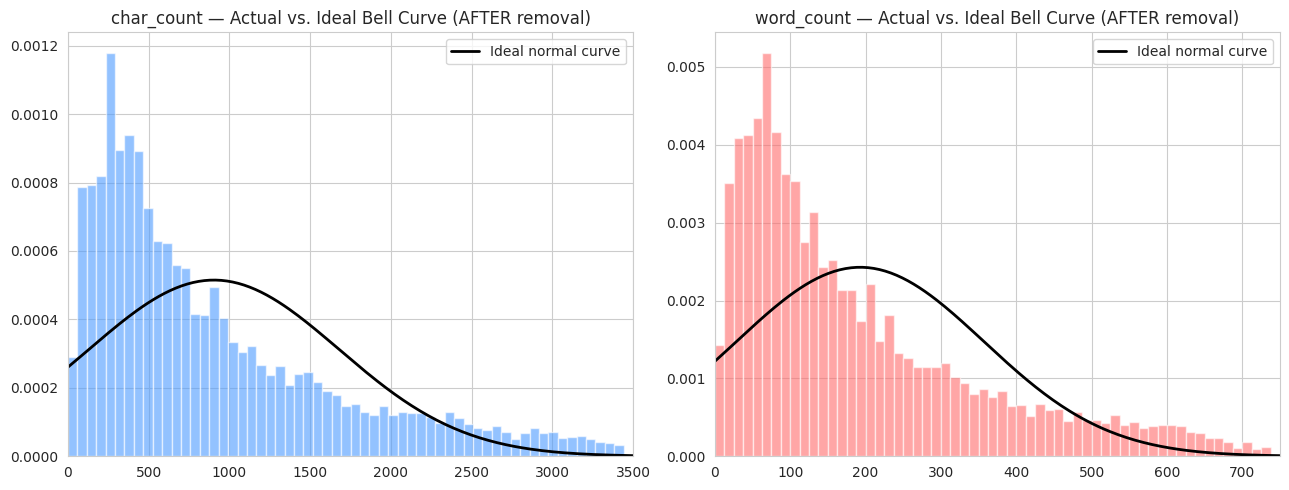

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

configs = [("char_count", "#4C9AFF", 3500), ("word_count", "#FF6B6B", 750)]

for ax, (col, color, xlim) in zip(axes, configs):
    data = df_clean[col]
    ax.hist(data, bins=60, range=(0, xlim), density=True, color=color, alpha=0.6, edgecolor="white")

    mu, sigma = data.mean(), data.std()
    x = np.linspace(0, xlim, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", linewidth=2, label="Ideal normal curve")

    ax.set_xlim(0, xlim)
    ax.set_title(f"{col} — Actual vs. Ideal Bell Curve (AFTER removal)")
    ax.legend()

plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def run_pipeline(data, label_suffix=""):
    X_train, X_test, y_train, y_test = train_test_split(
        data["Message"], data["label_num"], test_size=0.2,
        random_state=42, stratify=data["label_num"]
    )

    tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
    X_train_vec = tfidf.fit_transform(X_train)
    X_test_vec = tfidf.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    metrics = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    }

    print(f"=== Results {label_suffix} ===")
    for k, v in metrics.items():
        print(f"{k.capitalize():10s}: {v:.4f}")
    print()
    print(classification_report(y_test, preds, target_names=["ham", "spam"]))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham","spam"], yticklabels=["ham","spam"])
    plt.title(f"Confusion Matrix {label_suffix}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    return metrics

=== Results (BEFORE outlier removal) ===
Accuracy  : 0.9731
Precision : 0.9701
Recall    : 0.9598
F1        : 0.9649

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      3182
        spam       0.97      0.96      0.96      1991

    accuracy                           0.97      5173
   macro avg       0.97      0.97      0.97      5173
weighted avg       0.97      0.97      0.97      5173



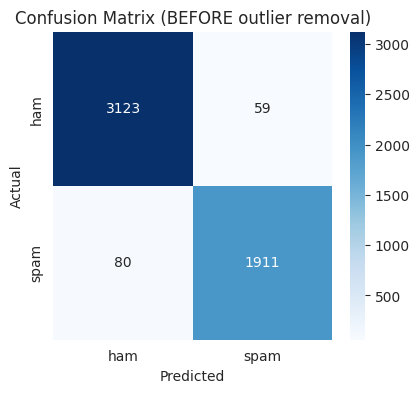

In [29]:
metrics_before = run_pipeline(df, label_suffix="(BEFORE outlier removal)")

=== Results (AFTER outlier removal) ===
Accuracy  : 0.9759
Precision : 0.9662
Recall    : 0.9715
F1        : 0.9688

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      2903
        spam       0.97      0.97      0.97      1822

    accuracy                           0.98      4725
   macro avg       0.97      0.98      0.97      4725
weighted avg       0.98      0.98      0.98      4725



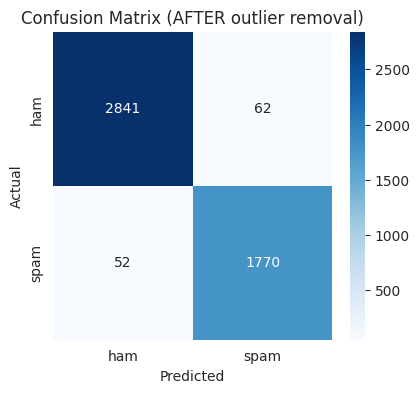

In [30]:
metrics_after = run_pipeline(df_clean, label_suffix="(AFTER outlier removal)")

In [31]:
comparison = pd.DataFrame({
    "Before outlier removal": metrics_before,
    "After outlier removal": metrics_after,
}).T

comparison

,accuracy,precision,recall,f1
Before outlier removal,0.973130,0.970051,0.959819,0.964908
After outlier removal,0.975873,0.966157,0.971460,0.968801


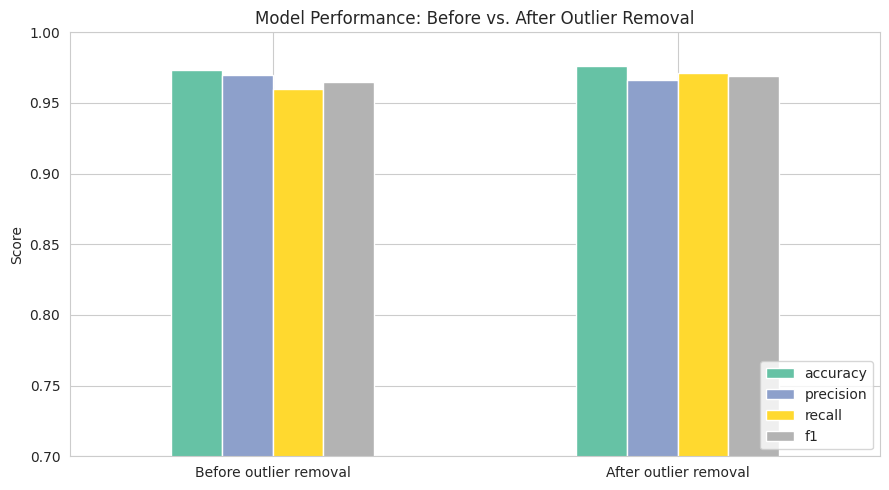

In [32]:
comparison.plot(kind="bar", figsize=(9, 5), colormap="Set2", ylim=(0.7, 1.0))
plt.title("Model Performance: Before vs. After Outlier Removal")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

# 1. Split the cleaned data
X_train, X_test, y_train, y_test = train_test_split(
    df_clean["Message"], df_clean["label_num"], test_size=0.2,
    random_state=42, stratify=df_clean["label_num"]
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")

# 2. Vectorize — fit ONLY on training data, then apply to test
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 3. Train the model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# 4. Predict on the held-out test set
preds = model.predict(X_test_vec)
probs = model.predict_proba(X_test_vec)  # confidence scores for each class

Training set size: 18897
Test set size:     4725


In [34]:
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)
roc_auc = roc_auc_score(y_test, probs[:, 1])  # uses spam confidence scores

print("=== Final Model Performance (test set, outlier-cleaned data) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print()
print(classification_report(y_test, preds, target_names=["ham", "spam"]))

cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:")
print(f"  True Negatives (ham correct):   {cm[0][0]}")
print(f"  False Positives (ham as spam):  {cm[0][1]}")
print(f"  False Negatives (spam as ham):  {cm[1][0]}")
print(f"  True Positives (spam correct):  {cm[1][1]}")

=== Final Model Performance (test set, outlier-cleaned data) ===
Accuracy:  0.9759
Precision: 0.9662
Recall:    0.9715
F1 Score:  0.9688
ROC-AUC:   0.9967

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      2903
        spam       0.97      0.97      0.97      1822

    accuracy                           0.98      4725
   macro avg       0.97      0.98      0.97      4725
weighted avg       0.98      0.98      0.98      4725

Confusion Matrix:
  True Negatives (ham correct):   2841
  False Positives (ham as spam):  62
  False Negatives (spam as ham):  52
  True Positives (spam correct):  1770


In [35]:
import numpy as np

# Default threshold is 0.5 — try a lower one to catch more spam
thresholds = [0.5, 0.4, 0.3, 0.2]

print(f"{'Threshold':<12}{'Recall':<10}{'Precision':<12}{'False Pos':<12}{'False Neg':<10}")
print("-" * 56)

for t in thresholds:
    preds_t = (probs[:, 1] >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_t)
    recall_t = recall_score(y_test, preds_t)
    precision_t = precision_score(y_test, preds_t)
    fp = cm_t[0][1]
    fn = cm_t[1][0]
    print(f"{t:<12}{recall_t:.4f}    {precision_t:.4f}      {fp:<12}{fn:<10}")

Threshold   Recall    Precision   False Pos   False Neg 
--------------------------------------------------------
0.5         0.9715    0.9662      62          52        
0.4         0.9808    0.9572      80          35        
0.3         0.9901    0.9455      104         18        
0.2         0.9956    0.9236      150         8         


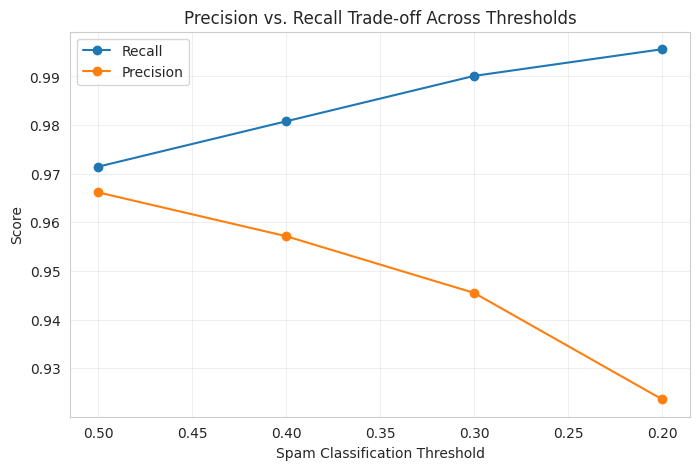

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, [recall_score(y_test, (probs[:,1]>=t).astype(int)) for t in thresholds], marker='o', label="Recall")
plt.plot(thresholds, [precision_score(y_test, (probs[:,1]>=t).astype(int)) for t in thresholds], marker='o', label="Precision")
plt.xlabel("Spam Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs. Recall Trade-off Across Thresholds")
plt.legend()
plt.gca().invert_xaxis()  # so it reads left-to-right as "stricter → looser"
plt.grid(alpha=0.3)
plt.show()

In [37]:
def predict_message(text):
    vec = tfidf.transform([text])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]

    label = "SPAM" if pred == 1 else "HAM"
    confidence = prob[pred] * 100

    print(f"Message: {text[:100]}{'...' if len(text) > 100 else ''}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"  (ham: {prob[0]*100:.2f}% | spam: {prob[1]*100:.2f}%)")
    print()

In [38]:
predict_message("Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!")
predict_message("Hey, are we still meeting for lunch tomorrow at 1pm?")
predict_message("URGENT: Your account will be suspended. Verify your password immediately at this link.")
predict_message("Please find attached the quarterly report for review before Friday's meeting.")

Message: Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!
Prediction: SPAM
Confidence: 95.97%
  (ham: 4.03% | spam: 95.97%)

Message: Hey, are we still meeting for lunch tomorrow at 1pm?
Prediction: HAM
Confidence: 96.37%
  (ham: 96.37% | spam: 3.63%)

Message: URGENT: Your account will be suspended. Verify your password immediately at this link.
Prediction: SPAM
Confidence: 74.64%
  (ham: 25.36% | spam: 74.64%)

Message: Please find attached the quarterly report for review before Friday's meeting.
Prediction: HAM
Confidence: 99.43%
  (ham: 99.43% | spam: 0.57%)

